### PLOTTER NOTEBOOK

In [1]:
import glob
import os
from codec import CodecSystem # Assuming codec.py contains the CodecSystem class

In [2]:
runname = 'timeSeries_1200k_clouds=10'
dirPath = os.path.join(os.getcwd(), runname)
# Search for files matching the pattern 'i=*.h5' in the directory
spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

# Initialize the results dictionary
specs = {}
codecs = {}

# Iterate through each file and load spectra
for index, file in enumerate(spectra_files):
    inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename
    
    specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
    codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

In [20]:
os.path.basename(spectra_files[0]).split('=')[1].split('.')[0]


'40'

### Plot all cloud codec images

Saved 60 panels images


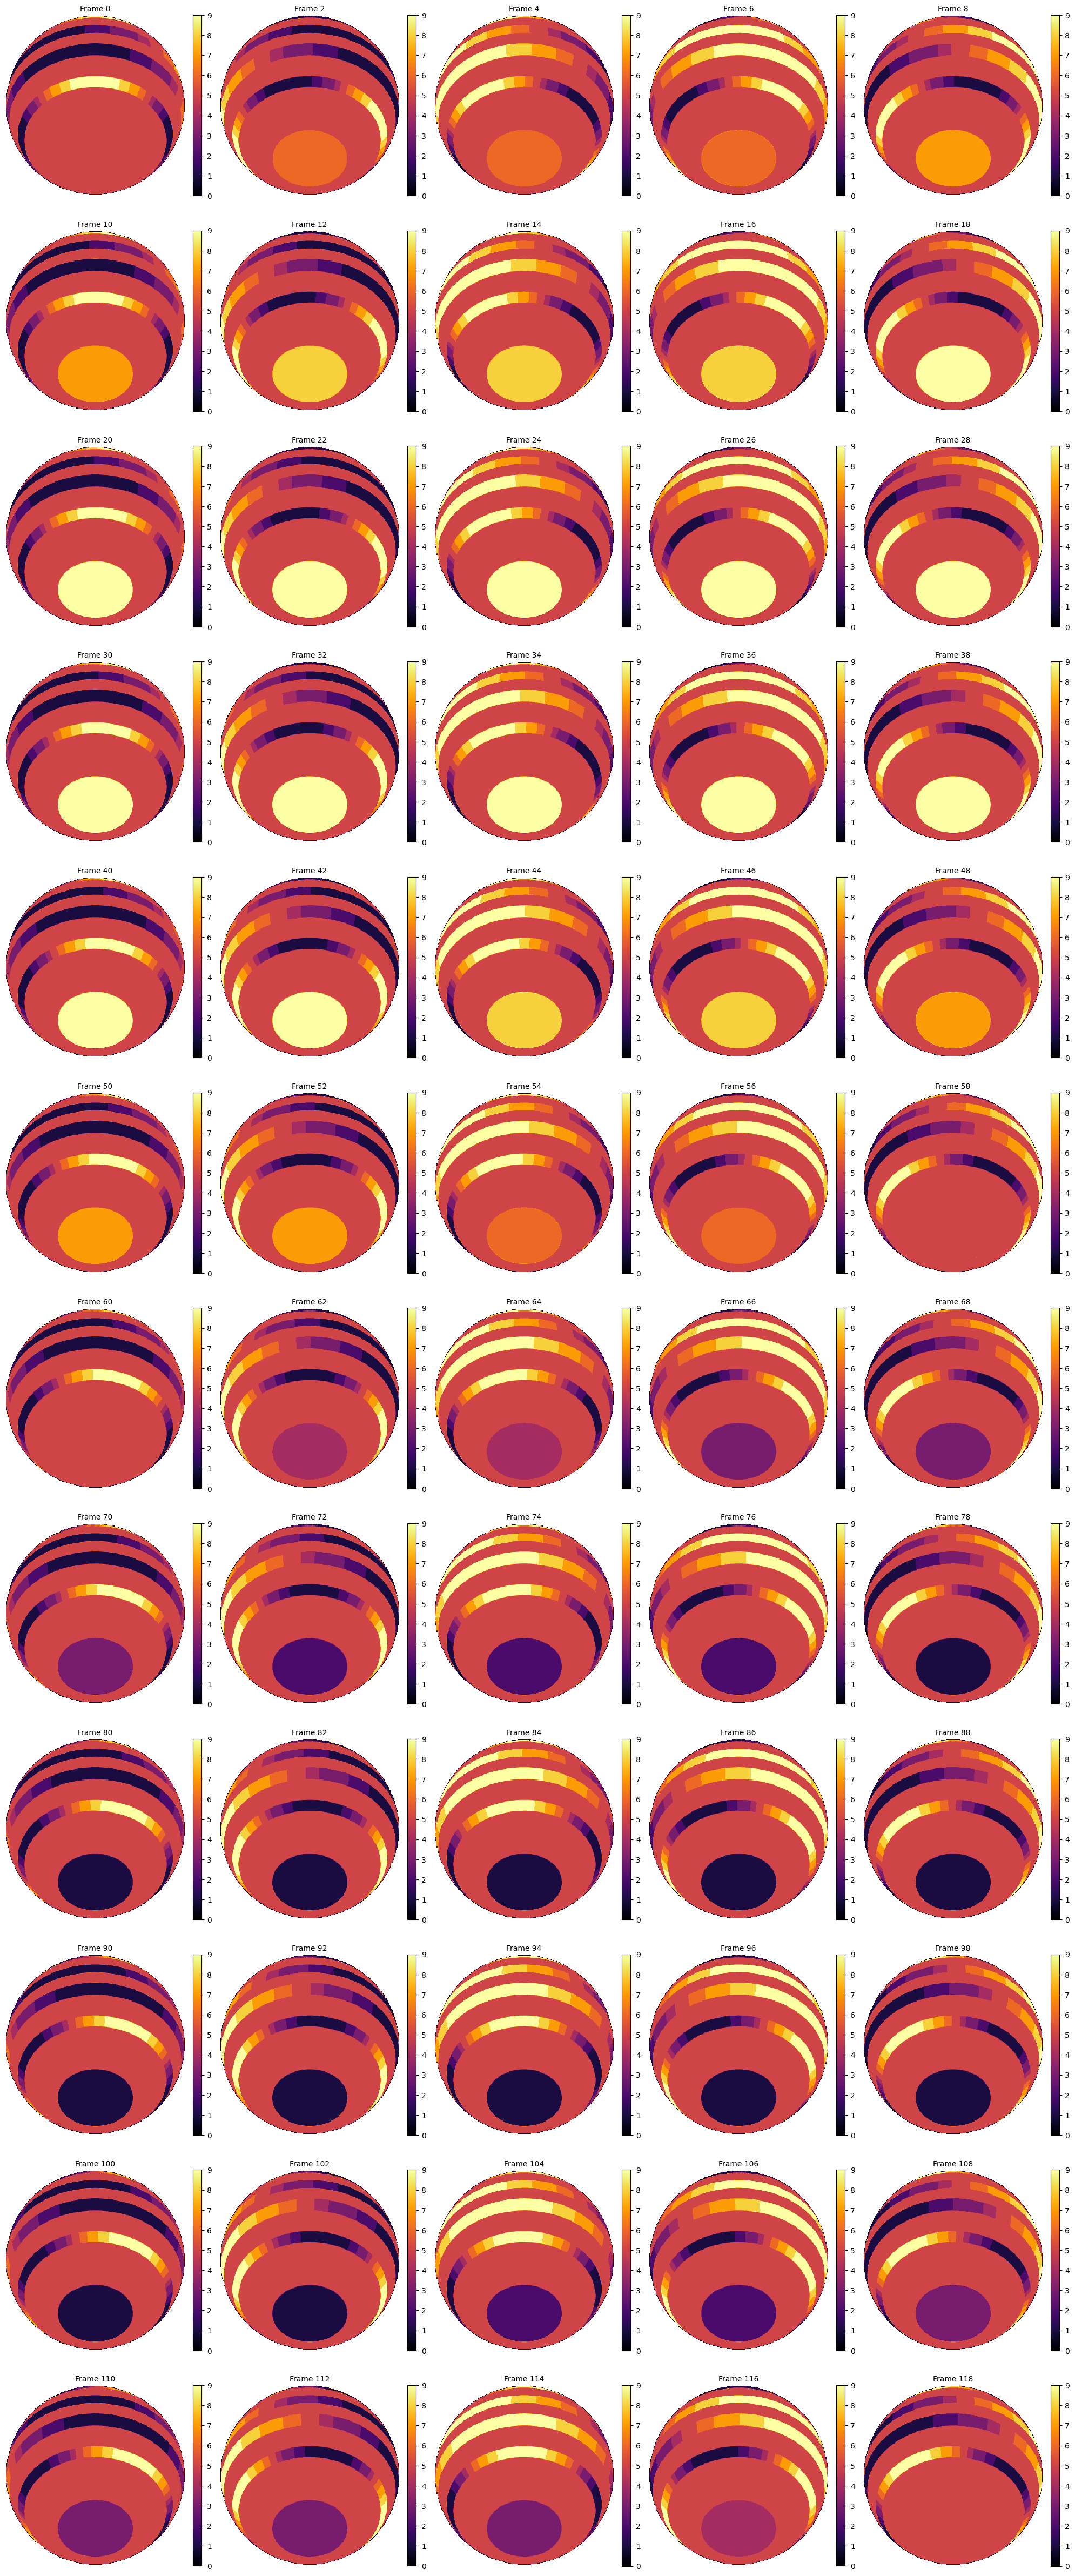

Saved 60 panels images


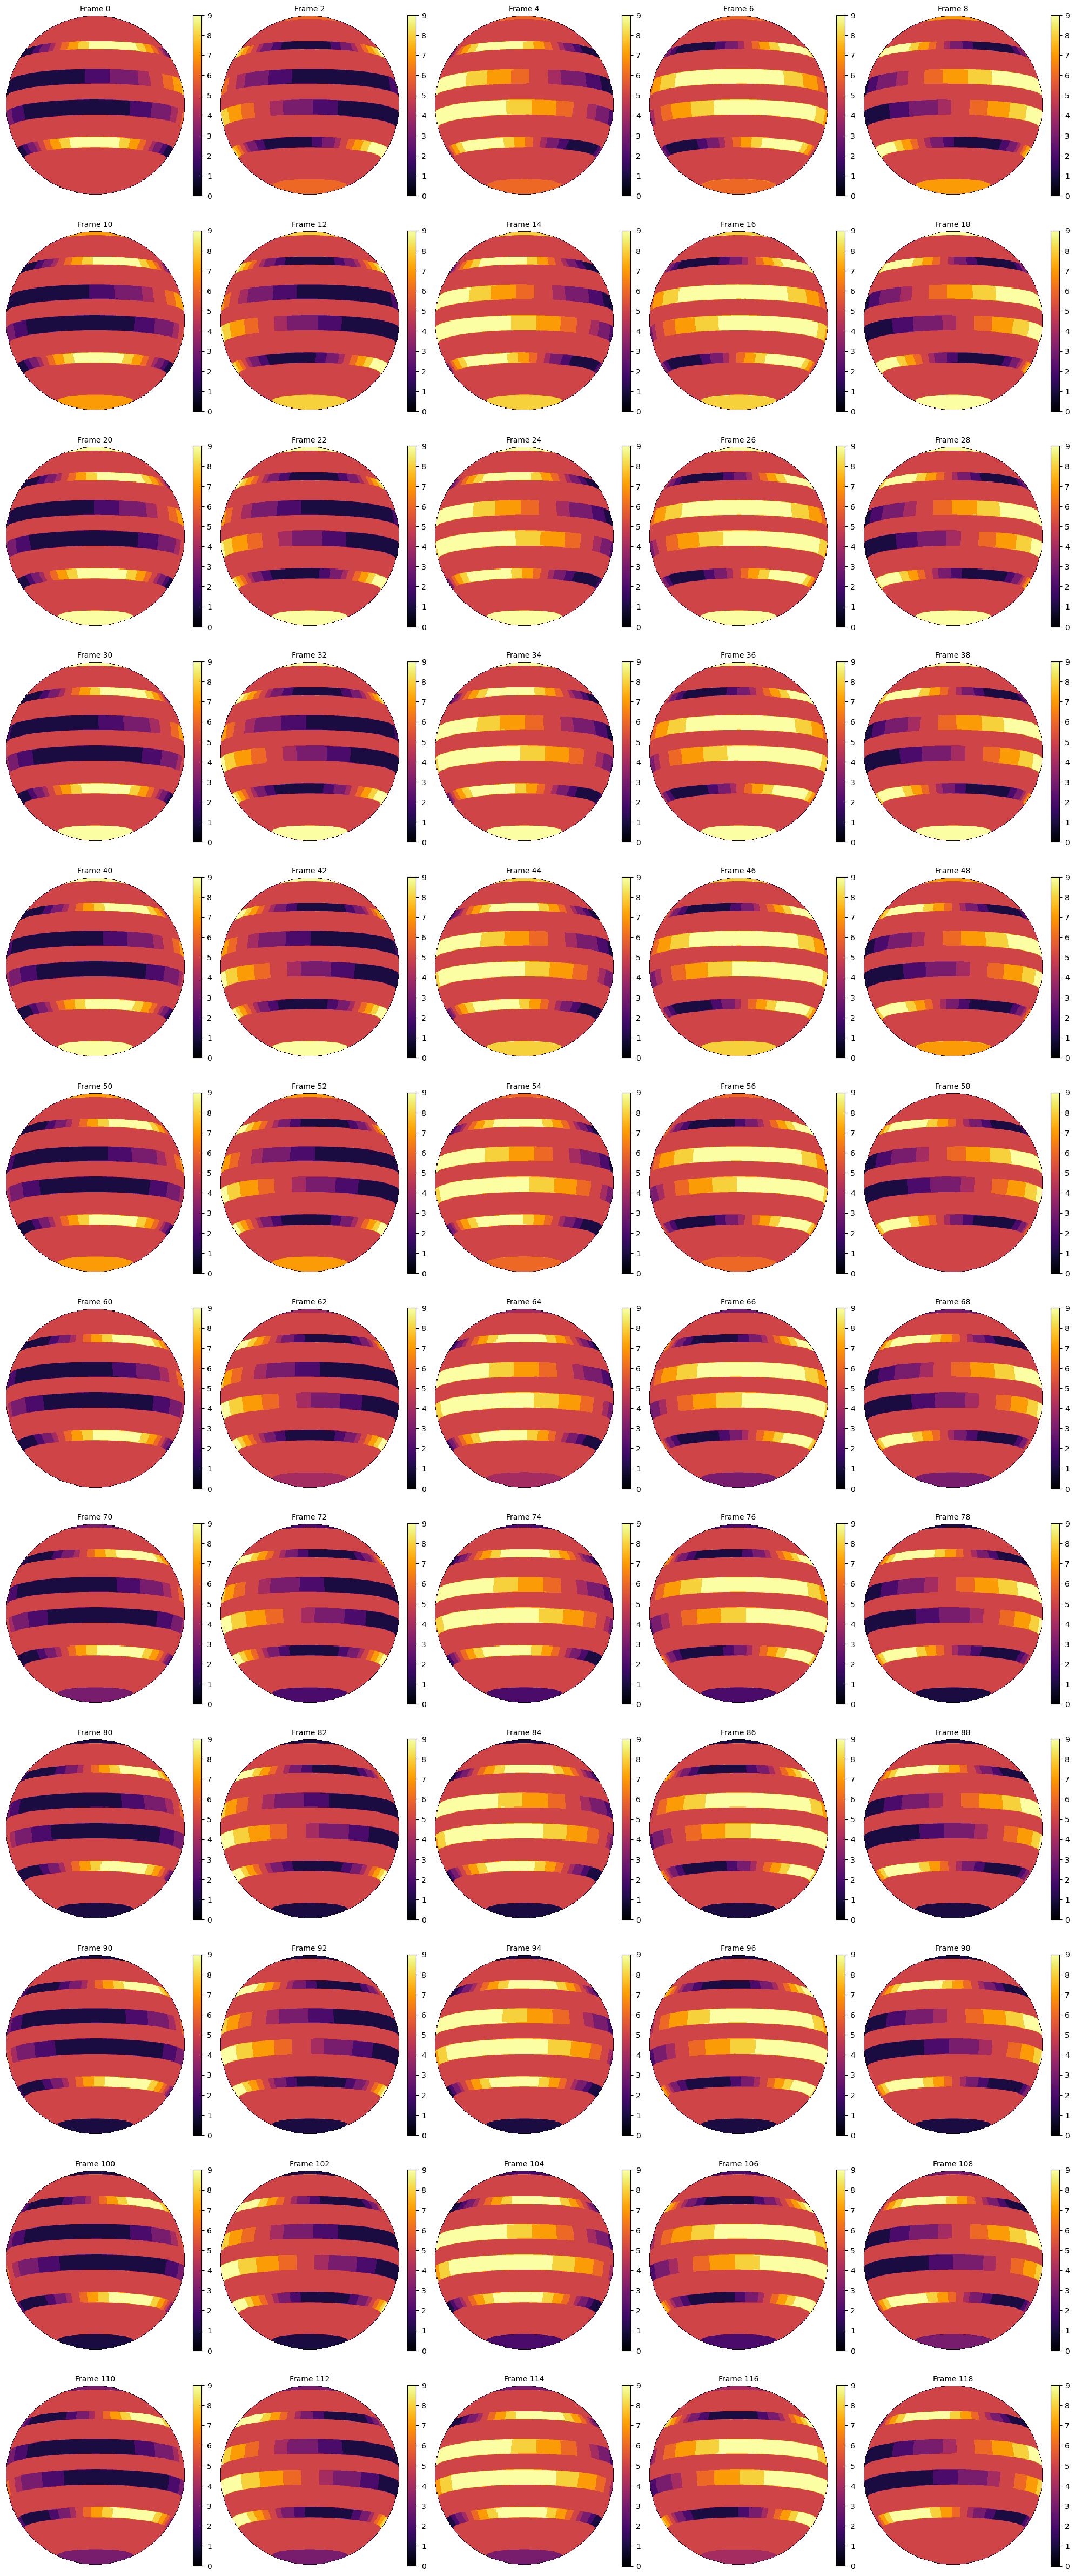

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

save = False
######## Plot all composite images in a grid (5 columns)

for inc in codecs.keys():
    codecs_ts = codecs[inc]
    
    n_frames = 60
    n_cols = 5
    n_rows = int(np.ceil(n_frames / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

    # Flatten axes for easier indexing
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    # Plot each frame
    for j in range(n_frames):
        i = 2*j  # Select every 2nd frame for visibility
        ax = axes_flat[j]
        composite = codecs_ts[i]['composite']
        frame_idx = codecs_ts[i]['frame']
        
        im = ax.imshow(composite, cmap='inferno', interpolation='nearest')
        ax.set_title(f'Frame {frame_idx}', fontsize=10)
        ax.axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused subplots
    for i in range(n_frames, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout()
    if save:
        outpath = os.path.join(dirPath, f'all_frames_i={inclin}.pdf')
        plt.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"Saved {n_frames}-panel image for i={inclin}")
    plt.show()
    plt.close()